In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
# to check results
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
print("STEP 1 DONE: All libraries imported")

STEP 1 DONE: All libraries imported


In [2]:
df = pd.read_excel("cleaned_merged_heart_dataset.xlsx")
le=LabelEncoder()
df["age"]=le.fit_transform(df["age"])
X=df.drop("target", axis=1)
y=df["target"]
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
scaler=StandardScaler()
x=scaler.fit_transform(X_train)
Y=scaler.transform(X_test)
smote=SMOTE(random_state=42)
xbal,ybal=smote.fit_resample(x,y_train)

In [3]:
model1=LogisticRegression(max_iter=2000,random_state=42)
model1.fit(xbal,ybal)
ypred=model1.predict(Y)
accuracy=accuracy_score(y_test,ypred)
recall=recall_score(y_test,ypred)
print(accuracy)
accuracy = accuracy_score(y_test, ypred)
recall = recall_score(y_test, ypred)
print(f"\n   Accuracy: {accuracy * 100:.2f}%")
print(f"   Recall  : {recall * 100:.2f}%")
print("\n   Detailed Report:")
print(classification_report(y_test, ypred,
      target_names=["No Heart Disease", "Heart Disease"]))

0.7372134038800705

   Accuracy: 73.72%
   Recall  : 78.16%

   Detailed Report:
                  precision    recall  f1-score   support

No Heart Disease       0.75      0.69      0.72       274
   Heart Disease       0.73      0.78      0.75       293

        accuracy                           0.74       567
       macro avg       0.74      0.74      0.74       567
    weighted avg       0.74      0.74      0.74       567



In [4]:
#model2 to be trained , pls
model2=KNeighborsClassifier(n_neighbors=6)
model2.fit(xbal,ybal)
ypred2=model2.predict(Y)
accuracy2=accuracy_score(y_test, ypred2)
recall2=recall_score(y_test, ypred2)
accuracy2 = accuracy_score(y_test, ypred2)
recall2 = recall_score(y_test, ypred2)
print(f"\n   Accuracy: {accuracy2 * 100:.2f}%")
print(f"   Recall  : {recall2 * 100:.2f}%")
print("\n   Detailed Report:")
print(classification_report(y_test, ypred2,
      target_names=["No Heart Disease", "Heart Disease"]))


   Accuracy: 86.07%
   Recall  : 84.98%

   Detailed Report:
                  precision    recall  f1-score   support

No Heart Disease       0.84      0.87      0.86       274
   Heart Disease       0.88      0.85      0.86       293

        accuracy                           0.86       567
       macro avg       0.86      0.86      0.86       567
    weighted avg       0.86      0.86      0.86       567



In [5]:
#model3 to be trained , pls
model_nb = GaussianNB() 
model_nb.fit(xbal, ybal)
 
# Predict
y_pred_nb = model_nb.predict(Y)
 
# Results
acc_nb = accuracy_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
print(f"\n   Accuracy: {acc_nb * 100:.2f}%")
print(f"   Recall  : {rec_nb * 100:.2f}%")
print("\n   Detailed Report:")
print(classification_report(y_test, y_pred_nb,
      target_names=["No Heart Disease", "Heart Disease"]))


   Accuracy: 68.96%
   Recall  : 78.16%

   Detailed Report:
                  precision    recall  f1-score   support

No Heart Disease       0.72      0.59      0.65       274
   Heart Disease       0.67      0.78      0.72       293

        accuracy                           0.69       567
       macro avg       0.69      0.69      0.69       567
    weighted avg       0.69      0.69      0.69       567



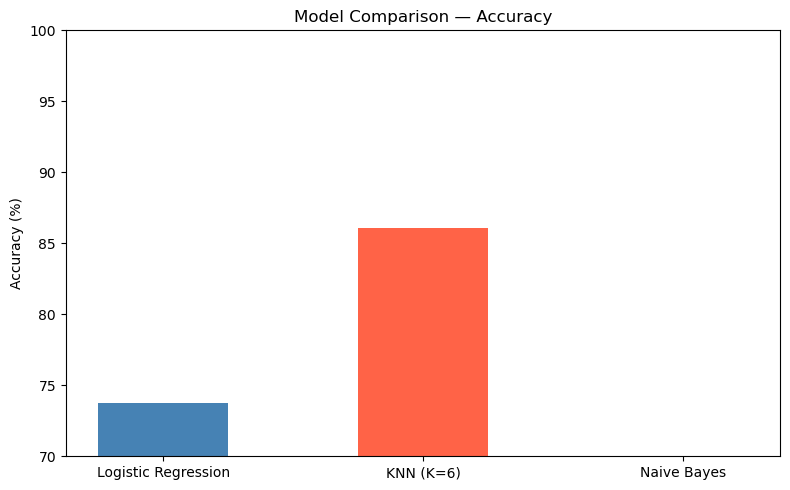

In [7]:
models      = ["Logistic Regression", "KNN (K=6)", "Naive Bayes"]
accuracies  = [accuracy * 100, accuracy2 * 100, acc_nb * 100]
recalls     = [recall * 100, recall2 * 100, rec_nb * 100]
plt.figure(figsize=(8, 5))
bar = plt.bar(models, accuracies, color=["steelblue", "tomato", "mediumseagreen"],
               width=0.5)
plt.ylim(70, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison — Accuracy")
plt.tight_layout()
plt.savefig("model_comparison1.png")
plt.show()
plt.close()

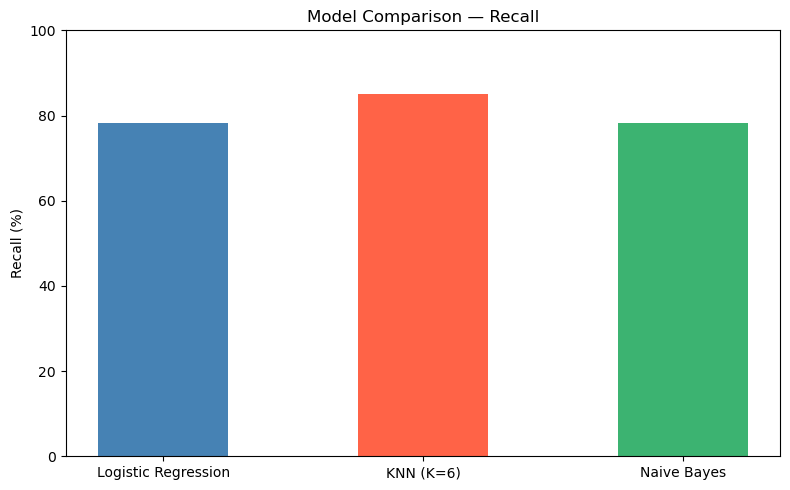

In [8]:
plt.figure(figsize=(8, 5))
bar2 = plt.bar(models, recalls, color=["steelblue", "tomato", "mediumseagreen"],
               width=0.5)
plt.ylim(0, 100)
plt.ylabel("Recall (%)")
plt.title("Model Comparison — Recall")
plt.tight_layout()
plt.savefig("model_comparison_recall.png")
plt.show()
plt.close()

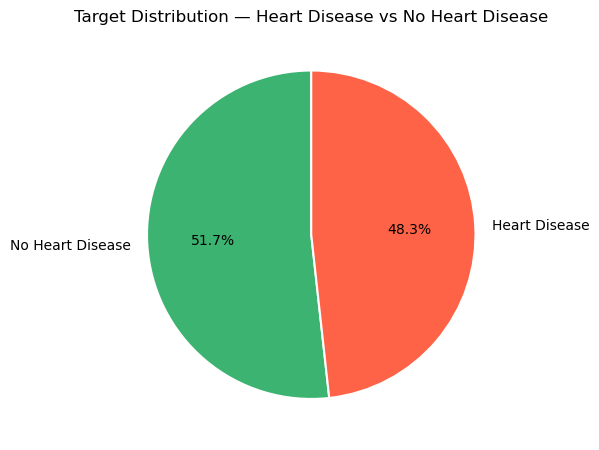

Chart saved: target_distribution_pie.png


In [9]:
target_counts = df["target"].value_counts()
labels        = ["No Heart Disease", "Heart Disease"]
colors        = ["mediumseagreen", "tomato"]
plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=labels, autopct="%1.1f%%",
        colors=colors, startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("Target Distribution — Heart Disease vs No Heart Disease")
plt.tight_layout()
plt.savefig("target_distribution_pie.png")
plt.show()
print("Chart saved: target_distribution_pie.png")